CANEDO_BELTRAN_BRAULIO_P02.ipynb
# Práctica 02 - Nueva prueba médica
Esta TAD tendrá como propósito resolver la problemática de **¿Tiene riesgo de sufrir un derrame cerebral?**. Para ello se creará la Unidad Muestral necesaria y limpiarán las variables necesarias. Tomando en cuenta lo mencionado en la descripción de la tarea se define lo siguinete:
- **Unidad Muestral:** los resultados durante la revisión *"equis"* de alguno de los paceintes.
- **Variable Objetivo ($y$):** tiene riesgo a sufrir un derrame cerebral, sí o no.
- **Valores de la $y$:** el valor de *"0"* para transacciones realizadas por menores a 50; y el valor de *"1"* para transacciones mayores o iguales a 50.

Elementos del código:
- Carga de Datos.
- Limpieza de Datos.
- Análisis exploratorio, tanto discretas/categóricas como continuas.
- Construcción de la TAD.

Indicaciones extras:
- Incluir al menos 3 nuevas variables en ingeniería de variables.
- Incluir la gráfica de tipo hist() de las variables **finales** de la TAD.
- Imprimir la TAD al final del código.

## Descripción (Macro) Variables
Para un entendimiento más sencilla del código y para facilitar la replicabilidad del mismo, se describe en le el apartado presente los términos con los que se nombrarán a tipos de variables y la estructura de las mismas.
- Variables del tipo *letras_*: estas variables contendrán la lista de nombres de variables que se buscan referenciar agrupadas por tipo de variable.
    - *um_*: la(s) variable(s) o combinación que sirve(n) como identificador único para cada registro.
    - *y_*: la variable objetivo que se busca pronosticar.
    - *c_*: todas aquellas variables categóricas que no se pueden sumar, restar, etc, o que sus operaciones matemáticas no tendrían sentido (ejemplo; código postal).
    - *v_*: todas aquellas variables de tipo númerico que indican cantidad de tiempo, dinero, distancia, granos, años, entre otros; con los cuales se pueden realitar operaciones que tienen sentido. 
    - *fh_*: todas las variables que indican un momento en específico en el tiempo y que están en fomrato de fecha y/o hora.
    - *dilit_*: aquellas variables que por alguna razón no se analizarán ni utilizarán.
    - *n_*: variables que han sido normalizadas.
    - *w_*: variables que se les ha asignado un valor numérico en relación con la variable respuesta.
- Prefijos en nombres de las variables: similar a las variables del tipo *letras_*, estas serán utilizadas para mayor facilidad al momento de idetificar lal variable y l amodificación ala cual fue sometida.

# Librerías

In [266]:
%time
# funciones optimización de ciclos
from functools import reduce

# manipulación de datos
import pandas as pd
import numpy as np

# manipulación de sistema
import os

# graficación
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# estadística
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,accuracy_score,confusion_matrix
from sklearn.linear_model import LogisticRegression

#
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.impute import SimpleImputer

# escribir parquet
import fastparquet

CPU times: user 10 μs, sys: 1 μs, total: 11 μs
Wall time: 16.7 μs


In [267]:
# Fromato para evitar notación ceintífica
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Importar Datos y Tipo de Datos

In [268]:
ruta = '/home/brauliocb/Documents/Diplomado/01_Modulo/Bases/healthcare.csv'

df = pd.read_csv(ruta)
df.sample(n=10, random_state=787)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3307,3205,Female,79.00,0,0,Yes,Self-employed,Urban,79.03,11.30,Unknown,0
364,71038,Male,34.00,0,0,Yes,Private,Urban,137.96,35.10,Unknown,0
1813,42465,Female,78.00,1,0,Yes,Private,Rural,58.66,16.40,never smoked,0
3352,50434,Male,38.00,0,0,Yes,Govt_job,Rural,135.74,31.30,formerly smoked,0
4862,49451,Female,53.00,0,0,Yes,Private,Rural,83.91,36.60,Unknown,0
1443,51124,Male,81.00,0,0,Yes,Self-employed,Urban,61.10,27.60,smokes,0
1563,47893,Male,63.00,0,0,Yes,Private,Rural,98.46,30.60,never smoked,0
3248,41182,Female,35.00,1,0,Yes,Private,Urban,94.20,34.40,smokes,0
4004,54240,Female,30.00,0,0,Yes,Govt_job,Urban,61.29,24.00,Unknown,0
3389,36728,Male,74.00,0,0,Yes,Private,Urban,79.44,32.80,never smoked,0


In [269]:
df.shape

(5110, 12)

In [270]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [271]:
df.dtypes

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

In [272]:
# revisamos si es necesario que los id, hypertension, heart_disease y stroke es necesario que sean así de grandes
print(f'Valor mínimo de {df['id'].name} es {df['id'].min()}; en cambio el valor máximo es {df['id'].max()}')
print(f'Valor mínimo de {df['hypertension'].name} es {df['hypertension'].min()}; en cambio el valor máximo es {df['hypertension'].max()}')
print(f'Valor mínimo de {df['heart_disease'].name} es {df['heart_disease'].min()}; en cambio el valor máximo es {df['heart_disease'].max()}')
print(f'Valor mínimo de {df['stroke'].name} es {df['stroke'].min()}; en cambio el valor máximo es {df['stroke'].max()}')
print(f'Valor mínimo de {df['age'].name} es {df['age'].min()}; en cambio el valor máximo es {df['age'].max()}')

Valor mínimo de id es 67; en cambio el valor máximo es 72940
Valor mínimo de hypertension es 0; en cambio el valor máximo es 1
Valor mínimo de heart_disease es 0; en cambio el valor máximo es 1
Valor mínimo de stroke es 0; en cambio el valor máximo es 1
Valor mínimo de age es 0.08; en cambio el valor máximo es 82.0


In [273]:
# revismaos solo para comprobar que sea binarias/booleanas las variables
print(f'Valores únicos de {df['hypertension'].name} {df['hypertension'].unique()}')
print(f'Valores únicos de {df['heart_disease'].name} {df['heart_disease'].unique()}')
print(f'Valores únicos de {df['stroke'].name} {df['stroke'].unique()}')

Valores únicos de hypertension [0 1]
Valores únicos de heart_disease [1 0]
Valores únicos de stroke [1 0]


In [274]:
# contamos los números con decimales en age
df['age_int'] = df['age']-df['age'].round()
df[df['age_int']>0]['age'].shape[0], df.shape[0], df[df['age_int']>0]['age'].shape[0]/df.shape[0]


(57, 5110, 0.011154598825831703)

In [275]:
# corroboramos que los id sean valores sin duplicados
len(df['id'].unique()), df.shape[0]

(5110, 5110)

In [276]:
# verificamos que a nivel registro no haya tipos de variables incongruentes
for c in df.columns:
    print(c, df[c].map(type).unique().tolist() )

id [<class 'int'>]
gender [<class 'str'>]
age [<class 'float'>]
hypertension [<class 'int'>]
heart_disease [<class 'int'>]
ever_married [<class 'str'>]
work_type [<class 'str'>]
Residence_type [<class 'str'>]
avg_glucose_level [<class 'float'>]
bmi [<class 'float'>]
smoking_status [<class 'str'>]
stroke [<class 'int'>]
age_int [<class 'float'>]


In [277]:
# para tener conocimiento previo de los nulos, realizamos un conteo por vairbale
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
age_int                0
dtype: int64

## Correcciones Empíricas

In [278]:
# añadimos le nueva edad en meses
df.drop(columns=['age_int'], inplace=True)
df['age_months'] = df['age']*12 
df['age_months'] = np.floor(df['age_months']) # modificar para que redondee al entero anterior
df.rename(columns={'age' : 'age_years'}, inplace=True)
df['age_years'] = np.floor(df['age_years']) # modificar para que redondee al entero anterior

In [312]:
# modificamos hypertension, heart_disease y stroke a vairable s de menos memoria
df['hypertension'] = df['hypertension'].astype('Int32')
df['heart_disease'] = df['heart_disease'].astype('Int32')
df['stroke'] = df['stroke'].astype('Int32')
df['age_years'] = df['age_years'].astype('Int32')
df['age_months'] = df['age_months'].astype('Int32')
df['id'] = df['id'].astype('str')
df.dtypes

KeyError: 'hypertension'

In [280]:
df.sample(n= 10, random_state=787)

,id,gender,age_years,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_months
3307,3205,Female,79,0,0,Yes,Self-employed,Urban,79.03,11.30,Unknown,0,948
364,71038,Male,34,0,0,Yes,Private,Urban,137.96,35.10,Unknown,0,408
1813,42465,Female,78,1,0,Yes,Private,Rural,58.66,16.40,never smoked,0,936
3352,50434,Male,38,0,0,Yes,Govt_job,Rural,135.74,31.30,formerly smoked,0,456
4862,49451,Female,53,0,0,Yes,Private,Rural,83.91,36.60,Unknown,0,636
1443,51124,Male,81,0,0,Yes,Self-employed,Urban,61.10,27.60,smokes,0,972
1563,47893,Male,63,0,0,Yes,Private,Rural,98.46,30.60,never smoked,0,756
3248,41182,Female,35,1,0,Yes,Private,Urban,94.20,34.40,smokes,0,420
4004,54240,Female,30,0,0,Yes,Govt_job,Urban,61.29,24.00,Unknown,0,360
3389,36728,Male,74,0,0,Yes,Private,Urban,79.44,32.80,never smoked,0,888


# Ingeniería de Variables

In [281]:
# indice de años y meses vividos contra  nivel promedio de glucosa
df['idx_agey_glucose'] = df['age_years']/df['avg_glucose_level']
df['idx_agem_glucose'] = df['age_months']/df['avg_glucose_level']
df.sample(n=10, random_state=787)

,id,gender,age_years,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_months,idx_agey_glucose,idx_agem_glucose
3307,3205,Female,79,0,0,Yes,Self-employed,Urban,79.03,11.30,Unknown,0,948,1.00,12.00
364,71038,Male,34,0,0,Yes,Private,Urban,137.96,35.10,Unknown,0,408,0.25,2.96
1813,42465,Female,78,1,0,Yes,Private,Rural,58.66,16.40,never smoked,0,936,1.33,15.96
3352,50434,Male,38,0,0,Yes,Govt_job,Rural,135.74,31.30,formerly smoked,0,456,0.28,3.36
4862,49451,Female,53,0,0,Yes,Private,Rural,83.91,36.60,Unknown,0,636,0.63,7.58
1443,51124,Male,81,0,0,Yes,Self-employed,Urban,61.10,27.60,smokes,0,972,1.33,15.91
1563,47893,Male,63,0,0,Yes,Private,Rural,98.46,30.60,never smoked,0,756,0.64,7.68
3248,41182,Female,35,1,0,Yes,Private,Urban,94.20,34.40,smokes,0,420,0.37,4.46
4004,54240,Female,30,0,0,Yes,Govt_job,Urban,61.29,24.00,Unknown,0,360,0.49,5.87
3389,36728,Male,74,0,0,Yes,Private,Urban,79.44,32.80,never smoked,0,888,0.93,11.18


In [282]:
# indice de años y meses vividos contra  nivel promedio de glucosa
df['idx_glucose_agey'] = df['avg_glucose_level']/df['age_years']
df['idx_glucose_agem'] = df['avg_glucose_level']/df['age_months']
df.sample(n=10, random_state=787)

,id,gender,age_years,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_months,idx_agey_glucose,idx_agem_glucose,idx_glucose_agey,idx_glucose_agem
3307,3205,Female,79,0,0,Yes,Self-employed,Urban,79.03,11.30,Unknown,0,948,1.00,12.00,1.00,0.08
364,71038,Male,34,0,0,Yes,Private,Urban,137.96,35.10,Unknown,0,408,0.25,2.96,4.06,0.34
1813,42465,Female,78,1,0,Yes,Private,Rural,58.66,16.40,never smoked,0,936,1.33,15.96,0.75,0.06
3352,50434,Male,38,0,0,Yes,Govt_job,Rural,135.74,31.30,formerly smoked,0,456,0.28,3.36,3.57,0.30
4862,49451,Female,53,0,0,Yes,Private,Rural,83.91,36.60,Unknown,0,636,0.63,7.58,1.58,0.13
1443,51124,Male,81,0,0,Yes,Self-employed,Urban,61.10,27.60,smokes,0,972,1.33,15.91,0.75,0.06
1563,47893,Male,63,0,0,Yes,Private,Rural,98.46,30.60,never smoked,0,756,0.64,7.68,1.56,0.13
3248,41182,Female,35,1,0,Yes,Private,Urban,94.20,34.40,smokes,0,420,0.37,4.46,2.69,0.22
4004,54240,Female,30,0,0,Yes,Govt_job,Urban,61.29,24.00,Unknown,0,360,0.49,5.87,2.04,0.17
3389,36728,Male,74,0,0,Yes,Private,Urban,79.44,32.80,never smoked,0,888,0.93,11.18,1.07,0.09


In [283]:
# indice de años y meses vividos contra bmi
df['idx_agey_bmi'] = df['age_years']/df['avg_glucose_level']
df['idx_agem_bmi'] = df['age_months']/df['avg_glucose_level']
df.sample(n=10, random_state=787)

,id,gender,age_years,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_months,idx_agey_glucose,idx_agem_glucose,idx_glucose_agey,idx_glucose_agem,idx_agey_bmi,idx_agem_bmi
3307,3205,Female,79,0,0,Yes,Self-employed,Urban,79.03,11.30,Unknown,0,948,1.00,12.00,1.00,0.08,1.00,12.00
364,71038,Male,34,0,0,Yes,Private,Urban,137.96,35.10,Unknown,0,408,0.25,2.96,4.06,0.34,0.25,2.96
1813,42465,Female,78,1,0,Yes,Private,Rural,58.66,16.40,never smoked,0,936,1.33,15.96,0.75,0.06,1.33,15.96
3352,50434,Male,38,0,0,Yes,Govt_job,Rural,135.74,31.30,formerly smoked,0,456,0.28,3.36,3.57,0.30,0.28,3.36
4862,49451,Female,53,0,0,Yes,Private,Rural,83.91,36.60,Unknown,0,636,0.63,7.58,1.58,0.13,0.63,7.58
1443,51124,Male,81,0,0,Yes,Self-employed,Urban,61.10,27.60,smokes,0,972,1.33,15.91,0.75,0.06,1.33,15.91
1563,47893,Male,63,0,0,Yes,Private,Rural,98.46,30.60,never smoked,0,756,0.64,7.68,1.56,0.13,0.64,7.68
3248,41182,Female,35,1,0,Yes,Private,Urban,94.20,34.40,smokes,0,420,0.37,4.46,2.69,0.22,0.37,4.46
4004,54240,Female,30,0,0,Yes,Govt_job,Urban,61.29,24.00,Unknown,0,360,0.49,5.87,2.04,0.17,0.49,5.87
3389,36728,Male,74,0,0,Yes,Private,Urban,79.44,32.80,never smoked,0,888,0.93,11.18,1.07,0.09,0.93,11.18


In [284]:
# indice de años y meses vividos contra bmi
df['idx_bmi_agey'] = df['bmi']/df['age_years']
df['idx_bmi_agem'] = df['bmi']/df['age_months']
df.sample(n=10, random_state=787)

,id,gender,age_years,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,...,stroke,age_months,idx_agey_glucose,idx_agem_glucose,idx_glucose_agey,idx_glucose_agem,idx_agey_bmi,idx_agem_bmi,idx_bmi_agey,idx_bmi_agem
3307,3205,Female,79,0,0,Yes,Self-employed,Urban,79.03,11.30,...,0,948,1.00,12.00,1.00,0.08,1.00,12.00,0.14,0.01
364,71038,Male,34,0,0,Yes,Private,Urban,137.96,35.10,...,0,408,0.25,2.96,4.06,0.34,0.25,2.96,1.03,0.09
1813,42465,Female,78,1,0,Yes,Private,Rural,58.66,16.40,...,0,936,1.33,15.96,0.75,0.06,1.33,15.96,0.21,0.02
3352,50434,Male,38,0,0,Yes,Govt_job,Rural,135.74,31.30,...,0,456,0.28,3.36,3.57,0.30,0.28,3.36,0.82,0.07
4862,49451,Female,53,0,0,Yes,Private,Rural,83.91,36.60,...,0,636,0.63,7.58,1.58,0.13,0.63,7.58,0.69,0.06
1443,51124,Male,81,0,0,Yes,Self-employed,Urban,61.10,27.60,...,0,972,1.33,15.91,0.75,0.06,1.33,15.91,0.34,0.03
1563,47893,Male,63,0,0,Yes,Private,Rural,98.46,30.60,...,0,756,0.64,7.68,1.56,0.13,0.64,7.68,0.49,0.04
3248,41182,Female,35,1,0,Yes,Private,Urban,94.20,34.40,...,0,420,0.37,4.46,2.69,0.22,0.37,4.46,0.98,0.08
4004,54240,Female,30,0,0,Yes,Govt_job,Urban,61.29,24.00,...,0,360,0.49,5.87,2.04,0.17,0.49,5.87,0.80,0.07
3389,36728,Male,74,0,0,Yes,Private,Urban,79.44,32.80,...,0,888,0.93,11.18,1.07,0.09,0.93,11.18,0.44,0.04


In [285]:
# indice de bmi entres nivel promedio de glucosa
df['idx_bmi_glucose'] = df['bmi']/df['avg_glucose_level']
df.sample(n=10, random_state=787)

,id,gender,age_years,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,...,age_months,idx_agey_glucose,idx_agem_glucose,idx_glucose_agey,idx_glucose_agem,idx_agey_bmi,idx_agem_bmi,idx_bmi_agey,idx_bmi_agem,idx_bmi_glucose
3307,3205,Female,79,0,0,Yes,Self-employed,Urban,79.03,11.30,...,948,1.00,12.00,1.00,0.08,1.00,12.00,0.14,0.01,0.14
364,71038,Male,34,0,0,Yes,Private,Urban,137.96,35.10,...,408,0.25,2.96,4.06,0.34,0.25,2.96,1.03,0.09,0.25
1813,42465,Female,78,1,0,Yes,Private,Rural,58.66,16.40,...,936,1.33,15.96,0.75,0.06,1.33,15.96,0.21,0.02,0.28
3352,50434,Male,38,0,0,Yes,Govt_job,Rural,135.74,31.30,...,456,0.28,3.36,3.57,0.30,0.28,3.36,0.82,0.07,0.23
4862,49451,Female,53,0,0,Yes,Private,Rural,83.91,36.60,...,636,0.63,7.58,1.58,0.13,0.63,7.58,0.69,0.06,0.44
1443,51124,Male,81,0,0,Yes,Self-employed,Urban,61.10,27.60,...,972,1.33,15.91,0.75,0.06,1.33,15.91,0.34,0.03,0.45
1563,47893,Male,63,0,0,Yes,Private,Rural,98.46,30.60,...,756,0.64,7.68,1.56,0.13,0.64,7.68,0.49,0.04,0.31
3248,41182,Female,35,1,0,Yes,Private,Urban,94.20,34.40,...,420,0.37,4.46,2.69,0.22,0.37,4.46,0.98,0.08,0.37
4004,54240,Female,30,0,0,Yes,Govt_job,Urban,61.29,24.00,...,360,0.49,5.87,2.04,0.17,0.49,5.87,0.80,0.07,0.39
3389,36728,Male,74,0,0,Yes,Private,Urban,79.44,32.80,...,888,0.93,11.18,1.07,0.09,0.93,11.18,0.44,0.04,0.41


# Análisis Exploratorio

## Macro Variables

In [286]:
# cambiamos el nombre de la variable stroke que es la vairable objetivo
df.rename(columns={'stroke' : 'y'}, inplace=True)

In [287]:
# Uniad Muestral
um_ = ['id']

# Variable Objetivo
y_ = ['y']

# Variables categóricas
c_ = df.drop(columns=um_).select_dtypes(include=['str','object']).columns.tolist()

# Variables numéricas
v_ = df.drop(columns=y_).select_dtypes(include=['Int32','int64','float64','Int8']).columns.tolist()

In [288]:
len(um_)+len(y_)+len(c_)+len(v_), df.shape[1]

(22, 22)

In [289]:
df.rename(columns={c:'v_'+c for c in v_}, inplace=True)
df.rename(columns={c:'c_'+c for c in c_}, inplace=True)

In [290]:
df.sample(n=10, random_state=787)

,id,c_gender,v_age_years,v_hypertension,v_heart_disease,c_ever_married,c_work_type,c_Residence_type,v_avg_glucose_level,v_bmi,...,v_age_months,v_idx_agey_glucose,v_idx_agem_glucose,v_idx_glucose_agey,v_idx_glucose_agem,v_idx_agey_bmi,v_idx_agem_bmi,v_idx_bmi_agey,v_idx_bmi_agem,v_idx_bmi_glucose
3307,3205,Female,79,0,0,Yes,Self-employed,Urban,79.03,11.30,...,948,1.00,12.00,1.00,0.08,1.00,12.00,0.14,0.01,0.14
364,71038,Male,34,0,0,Yes,Private,Urban,137.96,35.10,...,408,0.25,2.96,4.06,0.34,0.25,2.96,1.03,0.09,0.25
1813,42465,Female,78,1,0,Yes,Private,Rural,58.66,16.40,...,936,1.33,15.96,0.75,0.06,1.33,15.96,0.21,0.02,0.28
3352,50434,Male,38,0,0,Yes,Govt_job,Rural,135.74,31.30,...,456,0.28,3.36,3.57,0.30,0.28,3.36,0.82,0.07,0.23
4862,49451,Female,53,0,0,Yes,Private,Rural,83.91,36.60,...,636,0.63,7.58,1.58,0.13,0.63,7.58,0.69,0.06,0.44
1443,51124,Male,81,0,0,Yes,Self-employed,Urban,61.10,27.60,...,972,1.33,15.91,0.75,0.06,1.33,15.91,0.34,0.03,0.45
1563,47893,Male,63,0,0,Yes,Private,Rural,98.46,30.60,...,756,0.64,7.68,1.56,0.13,0.64,7.68,0.49,0.04,0.31
3248,41182,Female,35,1,0,Yes,Private,Urban,94.20,34.40,...,420,0.37,4.46,2.69,0.22,0.37,4.46,0.98,0.08,0.37
4004,54240,Female,30,0,0,Yes,Govt_job,Urban,61.29,24.00,...,360,0.49,5.87,2.04,0.17,0.49,5.87,0.80,0.07,0.39
3389,36728,Male,74,0,0,Yes,Private,Urban,79.44,32.80,...,888,0.93,11.18,1.07,0.09,0.93,11.18,0.44,0.04,0.41


In [291]:
c_ = [c for c in  df.columns.tolist() if c.startswith('c_') ]
v_ = [c for c in  df.columns.tolist() if c.startswith('v_') ]

In [292]:
c_

['c_gender',
 'c_ever_married',
 'c_work_type',
 'c_Residence_type',
 'c_smoking_status']

In [293]:
v_

['v_age_years',
 'v_hypertension',
 'v_heart_disease',
 'v_avg_glucose_level',
 'v_bmi',
 'v_age_months',
 'v_idx_agey_glucose',
 'v_idx_agem_glucose',
 'v_idx_glucose_agey',
 'v_idx_glucose_agem',
 'v_idx_agey_bmi',
 'v_idx_agem_bmi',
 'v_idx_bmi_agey',
 'v_idx_bmi_agem',
 'v_idx_bmi_glucose']

## Funciones

In [294]:
def calculo_iv(df , v, tgt, um):
    #v = 'n_week_day_2'
    aux = df.pivot_table( index = v , columns=tgt, values=um[0], aggfunc='count', fill_value=0 )
    aux[ list(range(2)) ] = aux/aux.apply(np.sum)
    aux['w'] = np.log( aux[0] / aux[1] )      ### AQUÍ ESTÁ LA FORMULA DEL WOE #####
    aux['iv'] = (aux[0] - aux[1])*aux['w']

    return v, aux['iv'].sum()

def clasificacion_woe(df , v, tgt, um):
    #v = 'n_week_day_2'
    aux = df.pivot_table( index = v ,
                          columns=tgt,
                         values=um[0],
                         aggfunc='count',
                         fill_value=0 )

    aux[ list(range(2)) ] = aux/aux.apply(np.sum)

    aux['w'] = np.log( aux[0] / aux[1] ) ### AQUÍ ESTÁ LA FORMULA DEL WOE #####

    aux.drop(range(2),axis=1,inplace=True)

    aux = aux.to_dict()['w']

    return v, aux

def freq(df, var):
    if type(var) != list:
        var = [var]
    for v in var:
        #v = 'state'
        aux = df[v].value_counts().to_frame().rename(columns={'count':'FA'})
        aux['FR'] = aux['FA'] / aux['FA'].sum()
        aux[['FAA','FRA']] = aux.apply(  np.cumsum )
        print(f"La variable: {v}")
        display(aux)
        print("\n")

def normalizar(df, v, umbral):
    #umbral = 0.03 # 0.05
    aux = df[v].value_counts(True).to_frame()
    aux[f"n_{v}"] = np.where( aux['proportion'] < umbral , 'CAT_PEQUE' ,aux.index )

    moda  = aux.head()[f'n_{v}'].values[0]

    if aux.loc[ aux[f'n_{v}'] == 'CAT_PEQUE' ]['proportion'].sum() < umbral:
        aux[f'n_{v}'].replace({'CAT_PEQUE':moda},inplace=True)

    aux.reset_index(inplace=True)

    return df.merge( aux , left_on=[v] , right_on=[v] , how='inner' ).drop('proportion',axis=1)

def discretizar(df_aux, v, k):

    kb = KBinsDiscretizer(n_bins=k, encode='ordinal', strategy='quantile', subsample=None)
    df_aux = df_aux.copy()

    # Asegurar que no haya valores NaN antes de discretizar
    df_aux[v] = pd.to_numeric(df_aux[v], errors='coerce')
    df_aux = df_aux.dropna(subset=[v])

    # Ajustar el discretizador
    kb.fit(df_aux[[v]])

    # Obtener los intervalos como strings usando pd.cut()
    bins = kb.bin_edges_[0]  # Extraer los límites de los bins
    df_aux[f'd_{v}_{k}'] = pd.cut(df_aux[v], bins=bins, include_lowest=True).astype(str)

    return df_aux

## Categóricas/Discretas

In [ ]:
for i in c_:
    print(f'{df[i].value_counts(True, dropna=False) * 100 }\n')

c_gender
Female   58.59
Male     41.39
Other     0.02
Name: proportion, dtype: float64

c_ever_married
Yes   65.62
No    34.38
Name: proportion, dtype: float64

c_work_type
Private         57.24
Self-employed   16.03
children        13.44
Govt_job        12.86
Never_worked     0.43
Name: proportion, dtype: float64

c_Residence_type
Urban   50.80
Rural   49.20
Name: proportion, dtype: float64

c_smoking_status
never smoked      37.03
Unknown           30.22
formerly smoked   17.32
smokes            15.44
Name: proportion, dtype: float64



In [311]:
df[y_].value_counts()

y
0    4861
1     249
Name: count, dtype: int64

In [297]:
c_

['c_gender',
 'c_ever_married',
 'c_work_type',
 'c_Residence_type',
 'c_smoking_status']

In [ ]:
c_

['c_gender',
 'c_ever_married',
 'c_work_type',
 'c_Residence_type',
 'c_smoking_status']

In [ ]:
c_

['c_gender',
 'c_ever_married',
 'c_work_type',
 'c_Residence_type',
 'c_smoking_status']

## Numércias/Continuas

In [ ]:
df_viajes['genero'].value_counts()/len(df_viajes)

In [6]:
# Revisamos cuántos NA tenemos
print(f'{df_viajes['genero'].isna().sum():,} {(df_viajes['genero'].isna().sum()/len(df_viajes))*100:.4}%')

452,232 3.34%


In [7]:
df_viajes = df_viajes.dropna(subset=['genero']).reset_index(drop=True)

In [8]:
# Revisamos si aún hay NA
df_viajes.isna().sum()

index              0
genero             0
edad               0
bici               2
estacion_retiro    0
estacion_arribo    0
tiempo_retiro      0
tiempo_arribo      0
duracion_min       0
dtype: int64

In [9]:
# Revisamos si aún hay NA
df_viajes = df_viajes.dropna(subset=['bici']).reset_index(drop=True)

In [10]:
# Revisamos si aún hay NA
df_viajes.isna().sum()

index              0
genero             0
edad               0
bici               0
estacion_retiro    0
estacion_arribo    0
tiempo_retiro      0
tiempo_arribo      0
duracion_min       0
dtype: int64

In [11]:
# Revisamos la cantidad de NA de manera general
df_viajes.head(5)

,index,genero,edad,bici,estacion_retiro,estacion_arribo,tiempo_retiro,tiempo_arribo,duracion_min
0,0,M,33,8041477,144,132,2022-10-31 23:57:44,2022-11-01 00:02:24,4.6667
1,1,M,26,7271174,116,097,2022-10-31 23:51:34,2022-11-01 00:03:47,12.2167
2,2,M,29,5345533,412,414,2022-10-31 23:52:07,2022-11-01 00:04:00,11.8833
3,3,M,26,3670049,324,374,2022-10-31 23:53:29,2022-11-01 00:05:11,11.7000
4,4,F,29,5867668,071,012,2022-10-31 23:52:48,2022-11-01 00:05:35,12.7833


In [12]:
# eliminamos la columna de index
del df_viajes['index']

In [13]:
# Revisamos la cantidad de NA de manera general
df_viajes.head(5)

,genero,edad,bici,estacion_retiro,estacion_arribo,tiempo_retiro,tiempo_arribo,duracion_min
0,M,33,8041477,144,132,2022-10-31 23:57:44,2022-11-01 00:02:24,4.6667
1,M,26,7271174,116,097,2022-10-31 23:51:34,2022-11-01 00:03:47,12.2167
2,M,29,5345533,412,414,2022-10-31 23:52:07,2022-11-01 00:04:00,11.8833
3,M,26,3670049,324,374,2022-10-31 23:53:29,2022-11-01 00:05:11,11.7000
4,F,29,5867668,071,012,2022-10-31 23:52:48,2022-11-01 00:05:35,12.7833


In [14]:
df = df_viajes
del df_viajes

### Duraciones Grandes

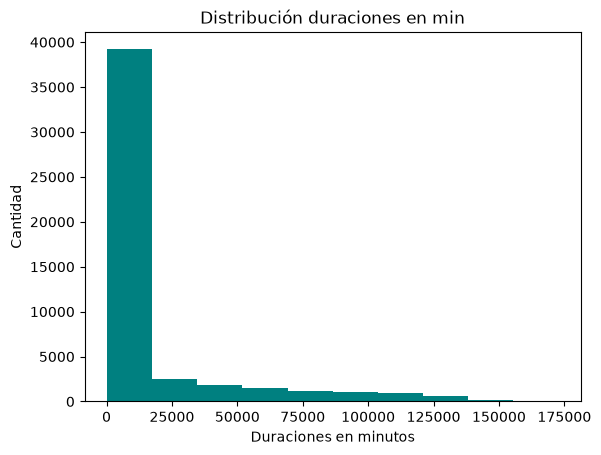

In [15]:
# Histograma sencillo: Cantidad de apariaciones de edades
aux_hist = df[df['duracion_min']>240]['duracion_min'].hist(
    color="#008080",#'teal',
    grid=False
    )

aux_hist.set_title('Distribución duraciones en min')
aux_hist.set_xlabel('Duraciones en minutos')
aux_hist.set_ylabel('Cantidad')

plt.show()

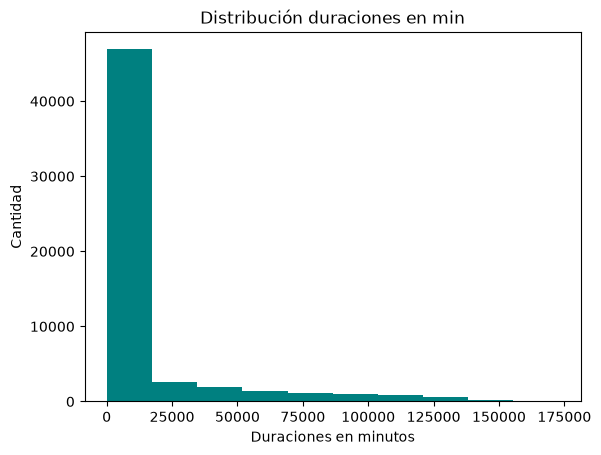

In [16]:
# Histograma sencillo: Cantidad de apariaciones de edades
aux_hist = df[df['duracion_min']>180]['duracion_min'].hist(
    color="#008080",#'teal',
    grid=False
    )

aux_hist.set_title('Distribución duraciones en min')
aux_hist.set_xlabel('Duraciones en minutos')
aux_hist.set_ylabel('Cantidad')

plt.show()

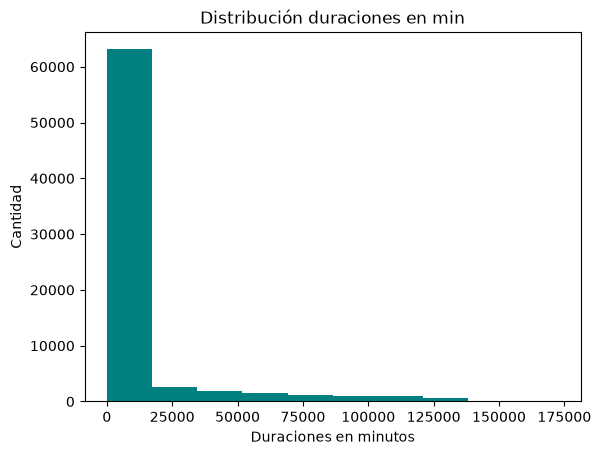

In [17]:
# Histograma sencillo: Cantidad de apariaciones de edades
aux_hist = df[df['duracion_min']>120]['duracion_min'].hist(
    color="#008080",#'teal',
    grid=False
    )
aux_hist.set_title('Distribución duraciones en min')

aux_hist.set_xlabel('Duraciones en minutos')
aux_hist.set_ylabel('Cantidad')

plt.show()

In [18]:
# Distribucion percentiles
df['duracion_min'].describe(np.arange(0,1.01,0.1))

count   13,088,894.0000
mean            45.3246
std          2,025.2212
min         -1,437.4333
0%          -1,437.4333
10%              4.2167
20%              6.1000
30%              7.8167
40%              9.6333
50%             11.7333
60%             14.3000
70%             17.6833
80%             22.6167
90%             31.1833
100%       172,598.0833
max        172,598.0833
Name: duracion_min, dtype: float64

In [19]:
# Proporcion de valores grandes
print(f'Proporción de duraciones grandes {(len(df[df['duracion_min']>120])/len(df))*100:.4}%')

Proporción de duraciones grandes 0.5575%


### Duraciones Negativas

In [20]:
# Proporciones de las duraciones negativas
print(f'Proporción de duraciones negativas {(df[df['duracion_min']<=0].shape[0]/df.shape[0])*100:.4}%')

Proporción de duraciones negativas 2.754%


In [21]:
# Información después de la limpieza
print(f'Registros antes {df.shape[0]:,} después {df.shape[0]-df[df['duracion_min']>120].shape[0]-df[df['duracion_min']<=0].shape[0]:,}')
print(f'Porcentaje de información tras eliminar {100-((df[df['duracion_min']>120].shape[0]+df[df['duracion_min']<=0].shape[0])/df.shape[0])*100:.4}%')

Registros antes 13,088,894 después 12,655,471
Porcentaje de información tras eliminar 96.69%


In [22]:
df = df[df['duracion_min']>0].reset_index(drop=True)

In [23]:
df = df[df['duracion_min']<=120].reset_index(drop=True)

In [24]:
df['duracion_min'].describe(np.arange(0,1.01,0.1))

count   12,655,471.0000
mean            15.5278
std             12.1267
min              0.0167
0%               0.0167
10%              4.7167
20%              6.4667
30%              8.1333
40%              9.9167
50%             11.9833
60%             14.5333
70%             17.8500
80%             22.6833
90%             30.9167
100%           120.0000
max            120.0000
Name: duracion_min, dtype: float64

### Corrección tipo datos

In [25]:
# volvemos a checar los tipos de datos
for c in df.columns:
    print(c, df[c].map(type).unique().tolist() )

genero [<class 'str'>]
edad [<class 'int'>]
bici [<class 'str'>]
estacion_retiro [<class 'str'>]
estacion_arribo [<class 'str'>]
tiempo_retiro [<class 'pandas.Timestamp'>]
tiempo_arribo [<class 'pandas.Timestamp'>]
duracion_min [<class 'float'>]


## Unidad Muestral
La unnidad muestral estará definida como la cantidad de mujeres que ocuparon bicicletas en cierto mes. Por lo que necesitamos una variable de tiempo que nos ayude a identificar el día ne el que se toma la bici indistinto de la hora.

In [26]:
df['mes_retiro'] = df['tiempo_retiro'].dt.to_period('M')
df

,genero,edad,bici,estacion_retiro,estacion_arribo,tiempo_retiro,tiempo_arribo,duracion_min,mes_retiro
0,M,33,8041477,144,132,2022-10-31 23:57:44,2022-11-01 00:02:24,4.6667,2022-10
1,M,26,7271174,116,097,2022-10-31 23:51:34,2022-11-01 00:03:47,12.2167,2022-10
2,M,29,5345533,412,414,2022-10-31 23:52:07,2022-11-01 00:04:00,11.8833,2022-10
3,M,26,3670049,324,374,2022-10-31 23:53:29,2022-11-01 00:05:11,11.7000,2022-10
4,F,29,5867668,071,012,2022-10-31 23:52:48,2022-11-01 00:05:35,12.7833,2022-10
...,...,...,...,...,...,...,...,...,...
12655466,F,26,8240,194.0,136.0,2020-07-31 19:01:33,2020-07-31 19:34:32,32.9833,2020-07
12655467,M,40,10722,154.0,181.0,2020-07-31 19:34:25,2020-07-31 19:48:24,13.9833,2020-07
12655468,M,30,10677,47.0,447.0,2020-07-31 19:44:17,2020-07-31 19:49:20,5.0500,2020-07
12655469,F,30,11661,254.0,259.0,2020-07-31 19:33:16,2020-07-31 19:59:31,26.2500,2020-07


In [27]:
um = 'mes_retiro'

In [28]:
pd.pivot_table(data = df, index = um , columns=['genero'], values=['bici'], aggfunc=['count'], fill_value=0 )

count               
              bici               
genero           F       M      O
mes_retiro                       
2019-12          2       5      0
2020-01     167552  507432      0
2020-02     174808  509776      0
2020-03     126899  399804      0
2020-04      34407  113412      0
2020-05      36108  110697      0
2020-06      44988  132688      0
2020-07      62588  168226      0
2020-08      70769  177442      0
2020-09      75014  188129      0
2020-10      87247  219721      0
2020-11      76917  197807      0
2020-12      68492  172524      0
2021-01      67556  158360      0
2021-02      78560  170163      0
2021-03      95990  212046      0
2021-04      94918  214651      0
2021-05     103303  234728      0
2021-06        233     591      0
2021-07      95945  236038      0
2021-08      90561  243494      0
2021-09      90885  245975      0
2021-10     110681  291260      0
2021-11     116559  302996      0
2021-12     109880  292077      0
2022-01     103683  271888      0
2022-02     116968  299741      0
2022-03     155104  382541      0
2022-04     145345  356413      0
2022-05     166408  409847      0
2022-06     146605  366791      0
2022-07     109441  286041      0
2022-08      90941  252387   1458
2022-09      84520  237738   7838
2022-10      55849  162985  12523
2022-11     106173  300295  14421
2022-12     104650  311929  14044

In [29]:
# Por la poca cantidad dregistro omitimos 31 dic 2019
df = df[df[um] >= '2020-01'].reset_index(drop=True)


In [30]:
df_g = df[df['genero']=='F'].groupby(um)['genero'].count().reset_index()
df_g.sample(5)

,mes_retiro,genero
11,2020-12,68492
25,2022-02,116968
27,2022-04,145345
14,2021-03,95990
33,2022-10,55849


In [31]:
df_g.rename(columns={'genero':'y'},inplace=True)

In [32]:
df_g.sample(5)

,mes_retiro,y
0,2020-01,167552
11,2020-12,68492
13,2021-02,78560
31,2022-08,90941
35,2022-12,104650


## Variables

In [33]:
y_ = 'genero'
df.columns

Index(['genero', 'edad', 'bici', 'estacion_retiro', 'estacion_arribo',
       'tiempo_retiro', 'tiempo_arribo', 'duracion_min', 'mes_retiro'],
      dtype='str')

### Continuas

In [34]:
aux = pd.pivot_table(df, index=um, columns=y_, values=['edad'], aggfunc=['sum','mean','median','max','min'], fill_value=0)

aux.columns = [f"v_{col[1]}_{col[0]}_{col[2]}" for col in aux.columns]

df_edad = aux.reset_index()

df_edad.sample(5)

,mes_retiro,v_edad_sum_F,v_edad_sum_M,v_edad_sum_O,v_edad_mean_F,v_edad_mean_M,v_edad_mean_O,v_edad_median_F,v_edad_median_M,v_edad_median_O,v_edad_max_F,v_edad_max_M,v_edad_max_O,v_edad_min_F,v_edad_min_M,v_edad_min_O
4,2020-05,1277979,4229079,0,35.3932,38.2041,0.0000,33.0000,36.0000,0.0000,88,80,0,17,17,0
21,2021-10,3760886,10656452,0,33.9795,36.5874,0.0000,32.0000,34.0000,0.0000,77,86,0,17,17,0
26,2022-03,5293874,14143119,0,34.1311,36.9715,0.0000,32.0000,34.0000,0.0000,77,87,0,18,18,0
18,2021-07,3312176,8791631,0,34.5216,37.2467,0.0000,32.0000,35.0000,0.0000,80,84,0,17,17,0
29,2022-06,4974326,13469611,0,33.9301,36.7229,0.0000,32.0000,34.0000,0.0000,77,83,0,18,18,0


In [35]:
aux = pd.pivot_table(df, index=um, columns=y_, values=['duracion_min'], aggfunc=['sum','mean','median','max','min'], fill_value=0)

aux.columns = [f"v_{col[1]}_{col[0]}_{col[2]}" for col in aux.columns]

df_duracion_min = aux.reset_index()

df_duracion_min.sample(5)

,mes_retiro,v_duracion_min_sum_F,v_duracion_min_sum_M,v_duracion_min_sum_O,v_duracion_min_mean_F,v_duracion_min_mean_M,v_duracion_min_mean_O,v_duracion_min_median_F,v_duracion_min_median_M,v_duracion_min_median_O,v_duracion_min_max_F,v_duracion_min_max_M,v_duracion_min_max_O,v_duracion_min_min_F,v_duracion_min_min_M,v_duracion_min_min_O
15,2021-04,"1,551,352.4833","3,292,173.1167",0.0000,16.3441,15.3373,0.0000,12.7500,11.5833,0.0000,119.7333,119.8500,0.0000,2.0000,2.0000,0.0000
6,2020-07,"1,026,333.1500","2,626,747.1000",0.0000,16.3982,15.6144,0.0000,12.9000,11.9500,0.0000,119.6167,120.0000,0.0000,2.0000,2.0000,0.0000
26,2022-03,"2,469,136.4500","5,749,227.5000",0.0000,15.9192,15.0290,0.0000,12.4333,11.5500,0.0000,119.8500,119.9833,0.0000,2.0000,2.0000,0.0000
30,2022-07,"1,851,909.6500","4,611,778.8833",0.0000,16.9215,16.1228,0.0000,13.0167,12.1667,0.0000,119.9167,120.0000,0.0000,2.0000,2.0000,0.0000
18,2021-07,"1,558,638.8000","3,596,584.9333",0.0000,16.2451,15.2373,0.0000,12.5833,11.5333,0.0000,119.2833,119.9333,0.0000,2.0000,2.0000,0.0000


### Fechas

In [36]:
df['mesnum_retiro'] = df['tiempo_retiro'].dt.month
df.sample(5)

,genero,edad,bici,estacion_retiro,estacion_arribo,tiempo_retiro,tiempo_arribo,duracion_min,mes_retiro,mesnum_retiro
4036823,F,36,7712060,126,110,2022-12-26 14:58:30,2022-12-26 15:07:56,9.4333,2022-12,12
5571654,F,30,8497,85.0,268.0,2020-05-25 15:11:09,2020-05-25 15:21:57,10.8000,2020-05,5
6157719,M,32,11096,135,189,2021-10-17 19:40:02,2021-10-17 20:14:11,34.1500,2021-10,10
884505,M,44,10817.0,38.0,271,2021-07-20 19:59:47,2021-07-20 20:25:41,25.9000,2021-07,7
5982082,M,41,7265,150,147,2021-10-04 12:44:12,2021-10-04 12:49:22,5.1667,2021-10,10


In [37]:
df['horanum_retiro'] = df['tiempo_retiro'].dt.hour
df.sample(5)

,genero,edad,bici,estacion_retiro,estacion_arribo,tiempo_retiro,tiempo_arribo,duracion_min,mes_retiro,mesnum_retiro,horanum_retiro
6347423,F,22,11294,238,51,2021-10-31 16:07:43,2021-10-31 17:00:28,52.7500,2021-10,10,16
1120943,F,35,9195.0,182.0,164.0,2022-04-19 19:28:53,2022-04-19 19:32:36,3.7167,2022-04,4,19
10438509,M,34,7048,151,67,2021-03-02 11:09:20,2021-03-02 11:16:27,7.1167,2021-03,3,11
9931218,M,74,7502,48,450,2021-04-20 03:32:01,2021-04-20 03:41:47,9.7667,2021-04,4,3
9250744,M,49,11016.0,226.0,252.0,2022-02-24 13:43:55,2022-02-24 13:51:49,7.9000,2022-02,2,13


In [38]:
aux = pd.pivot_table(df, index=um, columns=y_, values=['mesnum_retiro'], aggfunc=['sum','mean','median','max','min'], fill_value=0)

aux.columns = [f"f_{col[1]}_{col[0]}_{col[2]}" for col in aux.columns]

df_mesnum_retiro = aux.reset_index()

df_mesnum_retiro.sample(5)

,mes_retiro,f_mesnum_retiro_sum_F,f_mesnum_retiro_sum_M,f_mesnum_retiro_sum_O,f_mesnum_retiro_mean_F,f_mesnum_retiro_mean_M,f_mesnum_retiro_mean_O,f_mesnum_retiro_median_F,f_mesnum_retiro_median_M,f_mesnum_retiro_median_O,f_mesnum_retiro_max_F,f_mesnum_retiro_max_M,f_mesnum_retiro_max_O,f_mesnum_retiro_min_F,f_mesnum_retiro_min_M,f_mesnum_retiro_min_O
23,2021-12,1318560,3504924,0,12.0000,12.0000,0.0000,12.0000,12.0000,0.0000,12,12,0,12,12,0
21,2021-10,1106810,2912600,0,10.0000,10.0000,0.0000,10.0000,10.0000,0.0000,10,10,0,10,10,0
6,2020-07,438116,1177582,0,7.0000,7.0000,0.0000,7.0000,7.0000,0.0000,7,7,0,7,7,0
29,2022-06,879630,2200746,0,6.0000,6.0000,0.0000,6.0000,6.0000,0.0000,6,6,0,6,6,0
22,2021-11,1282149,3332956,0,11.0000,11.0000,0.0000,11.0000,11.0000,0.0000,11,11,0,11,11,0


In [39]:
aux = pd.pivot_table(df, index=um, columns=y_, values=['horanum_retiro'], aggfunc=['sum','mean','median','max','min'], fill_value=0)

aux.columns = [f"f_{col[1]}_{col[0]}_{col[2]}" for col in aux.columns]

df_horanum_retiro = aux.reset_index()

df_horanum_retiro.sample(5)

,mes_retiro,f_horanum_retiro_sum_F,f_horanum_retiro_sum_M,f_horanum_retiro_sum_O,f_horanum_retiro_mean_F,f_horanum_retiro_mean_M,f_horanum_retiro_mean_O,f_horanum_retiro_median_F,f_horanum_retiro_median_M,f_horanum_retiro_median_O,f_horanum_retiro_max_F,f_horanum_retiro_max_M,f_horanum_retiro_max_O,f_horanum_retiro_min_F,f_horanum_retiro_min_M,f_horanum_retiro_min_O
26,2022-03,2178270,5419972,0,14.0439,14.1683,0.0000,14.0000,14.0000,0.0000,23,23,0,0,0,0
25,2022-02,1656907,4271625,0,14.1655,14.2511,0.0000,14.0000,14.0000,0.0000,23,23,0,0,0,0
29,2022-06,2021881,5102384,0,13.7914,13.9109,0.0000,14.0000,14.0000,0.0000,23,23,0,0,0,0
7,2020-08,986361,2468267,0,13.9378,13.9103,0.0000,14.0000,14.0000,0.0000,23,23,0,0,0,0
2,2020-03,1743040,5541630,0,13.7356,13.8609,0.0000,14.0000,14.0000,0.0000,23,23,0,0,0,0


### Categóricas

In [47]:
aux = pd.pivot_table(df,index=um,columns=[y_,'estacion_retiro'],values='tiempo_retiro',aggfunc='count',fill_value=0)

aux.columns = [f"c_retiro_{col[0]}_{col[1]}" for col in aux.columns]

df_estacion_retiro = aux.reset_index()

df_estacion_retiro.sample(5)

,mes_retiro,c_retiro_F_002,c_retiro_F_003,c_retiro_F_005,c_retiro_F_006,c_retiro_F_007,c_retiro_F_010,c_retiro_F_012,c_retiro_F_016,c_retiro_F_019,...,c_retiro_O_461,c_retiro_O_464,c_retiro_O_466,c_retiro_O_467,c_retiro_O_468,c_retiro_O_469,c_retiro_O_472,c_retiro_O_475,c_retiro_O_479,c_retiro_O_555
10,2020-11,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29,2022-06,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,2020-09,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
34,2022-11,494,928,702,990,974,21,545,1605,1935,...,19,44,6,35,0,7,8,2,5,1
3,2020-04,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:
aux = pd.pivot_table(df,index=um,columns=[y_,'estacion_arribo'],values='tiempo_arribo',aggfunc='count',fill_value=0)

aux.columns = [f"c_arribo_{col[0]}_{col[1]}" for col in aux.columns]

df_estacion_arribo = aux.reset_index()

df_estacion_arribo.sample(5)

,mes_retiro,c_arribo_F_002,c_arribo_F_003,c_arribo_F_005,c_arribo_F_006,c_arribo_F_007,c_arribo_F_010,c_arribo_F_012,c_arribo_F_016,c_arribo_F_019,...,c_arribo_O_461,c_arribo_O_464,c_arribo_O_466,c_arribo_O_467,c_arribo_O_468,c_arribo_O_469,c_arribo_O_472,c_arribo_O_475,c_arribo_O_479,c_arribo_O_555
12,2021-01,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2020-02,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
30,2022-07,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,2021-04,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,2020-08,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Union de los data frames

In [49]:
X = reduce( lambda A,B: pd.merge( A,B, on=um, how='left') ,  [df_g ,
                                                              df_edad,
                                                              df_duracion_min,
                                                              df_mesnum_retiro,
                                                              df_horanum_retiro,
                                                              df_estacion_retiro,
                                                              df_estacion_arribo]) 

In [50]:
X.sample(10)

,mes_retiro,y,v_edad_sum_F,v_edad_sum_M,v_edad_sum_O,v_edad_mean_F,v_edad_mean_M,v_edad_mean_O,v_edad_median_F,v_edad_median_M,...,c_arribo_O_461,c_arribo_O_464,c_arribo_O_466,c_arribo_O_467,c_arribo_O_468,c_arribo_O_469,c_arribo_O_472,c_arribo_O_475,c_arribo_O_479,c_arribo_O_555
35,2022-12,104650,3566040,11370883,465608,34.0759,36.4534,33.1535,32.0000,34.0000,...,3,36,20,37,2,9,37,12,26,50
2,2020-03,126899,4264445,14532070,0,33.6050,36.3480,0.0000,31.0000,34.0000,...,0,0,0,0,0,0,0,0,0,0
4,2020-05,36108,1277979,4229079,0,35.3932,38.2041,0.0000,33.0000,36.0000,...,0,0,0,0,0,0,0,0,0,0
27,2022-04,145345,4941500,13107109,0,33.9984,36.7751,0.0000,32.0000,34.0000,...,0,0,0,0,0,0,0,0,0,0
24,2022-01,103683,3604878,10164326,0,34.7683,37.3842,0.0000,32.0000,35.0000,...,0,0,0,0,0,0,0,0,0,0
3,2020-04,34407,1213251,4327796,0,35.2617,38.1599,0.0000,33.0000,36.0000,...,0,0,0,0,0,0,0,0,0,0
32,2022-09,84520,2848858,8694121,248285,33.7063,36.5702,31.6771,32.0000,34.0000,...,0,0,0,0,0,0,0,0,0,0
19,2021-08,90561,3098379,9030715,0,34.2132,37.0880,0.0000,32.0000,34.0000,...,0,0,0,0,0,0,0,0,0,0
29,2022-06,146605,4974326,13469611,0,33.9301,36.7229,0.0000,32.0000,34.0000,...,0,0,0,0,0,0,0,0,0,0
5,2020-06,44988,1582691,5034774,0,35.1803,37.9445,0.0000,33.0000,35.0000,...,0,0,0,0,0,0,0,0,0,0


## Ventanas

In [ ]:
df.columns

Index(['genero', 'edad', 'bici', 'estacion_retiro', 'estacion_arribo',
       'tiempo_retiro', 'tiempo_arribo', 'duracion_min', 'mes_retiro'],
      dtype='str')

# Exportar TAD

In [ ]:
X[um] = X[um].astype(str)

X.to_parquet('Bases/CANEDO_BELTRAN_BRAULIO_P02.parquet',
                     engine = 'fastparquet')